In [11]:
from langgraph.graph import StateGraph,START,END
from langchain_groq import ChatGroq
from dotenv import load_dotenv
from typing import TypedDict,Literal,Annotated
from pydantic import Field,BaseModel
from langchain_core.messages import BaseMessage,HumanMessage
from langgraph.graph.message import add_messages
from langgraph.checkpoint.memory import MemorySaver

In [2]:
class Chatstate(TypedDict):
    messages:Annotated[list[BaseMessage],add_messages]

In [3]:
llm=ChatGroq(
    model="llama-3.3-70b-versatile",
    temperature=0.7
)

In [4]:
def chat_bot(state:Chatstate):
    messages=state['messages']
    response=llm.invoke(messages)

    return {'messages':[response]}

In [12]:
checkpointer=MemorySaver()
graph=StateGraph(Chatstate)
graph.add_node('chat_bot',chat_bot)
graph.add_edge(START,'chat_bot')
graph.add_edge('chat_bot',END)
chatbot=graph.compile(checkpointer=checkpointer)

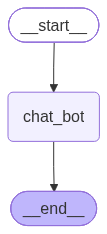

In [6]:
chatbot

In [7]:
initial_state={
    'messages':[HumanMessage(content='what is the capital of india')]
}

chatbot.invoke(initial_state)['messages'][-1].content

'The capital of India is **New Delhi**.'

In [14]:
thread_id='1'
while True:
    user_message=input('Type here :')
    print ('User:',user_message)

    if user_message.strip().lower() in ['exit','bye','quit']:
       break
    config={'configurable':{'thread_id':thread_id}}
    response=chatbot.invoke({'messages':[HumanMessage(content=user_message)]},config=config)
    print('Ai:',response['messages'][-1].content)


User: exit


In [15]:
chatbot.get_state(config=config)

StateSnapshot(values={'messages': [HumanMessage(content='hii', additional_kwargs={}, response_metadata={}, id='95576f31-781a-4151-80c9-a80248fc4034'), AIMessage(content="It's nice to meet you. Is there something I can help you with or would you like to chat?", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 23, 'prompt_tokens': 37, 'total_tokens': 60, 'completion_time': 0.06037529, 'completion_tokens_details': None, 'prompt_time': 0.001721338, 'prompt_tokens_details': None, 'queue_time': 0.051099481, 'total_time': 0.062096628}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_dae98b5ecb', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019fead3-ad32-7cf1-82b9-2c5c9371ecb3-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 37, 'output_tokens': 23, 'total_tokens': 60}), HumanMessage(content='my name is prateek', additional_kwargs={}, response_metadata={}, 